In [4]:
import pandas as pd  
import matplotlib.pyplot as plt 


In [ ]:
#adım1: gerekli kütüphaneleri yükleme
#adım2: csv dosyasını yükleyin  ve ilk 5 veriyi gösterin 
#adım3: eksik değerleri tespit etme 
#adım4:eksik değerleri ortalama ile doldurma
#adım5:en çok oynanan ilk 5 oyunu bulun
#adım6:en çok oynanan ilk 5 oyunu görselleştiren (grafik veya pasta)


In [5]:
df=pd.read_csv("data/oyunlar_listesi.csv")
print(df.head(5))

              oyunad     oyuntarz   yil  oynanma_oran
0     Tepedeki Savaş      Aksiyon  2021          61.0
1        Viking Ruhu        Korku  2022           NaN
2        Dinozor Avı        Korku  2002          47.0
3         Deniz Altı     Strateji  2008          56.0
4  Savaşçıların Çağı  Bilim-Kurgu  2016           NaN


In [8]:
eksik_değerler=df.isnull().sum()
print(eksik_değerler)

oyunad           0
oyuntarz         0
yil              0
oynanma_oran    16
dtype: int64


In [9]:
for columns in df.columns:
    if df[columns].isnull().sum()>0:
        mean_value=df[columns].mean()
        df[columns].fillna(mean_value,inplace=True)
        print()

<notebook cell>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[columns].fillna(mean_value,inplace=True)


In [10]:
top5_shows=df.nlargest(5,"oynanma_oran")
print(top5_shows[["oyunad","oynanma_oran"]])

                  oyunad  oynanma_oran
47             Buz Devri          89.0
23           Doğa Kaşifi          82.0
48  Galaksinin Savaşçısı          82.0
49            Ruh Avcısı          78.0
46      Yağmur Ormanları          75.0


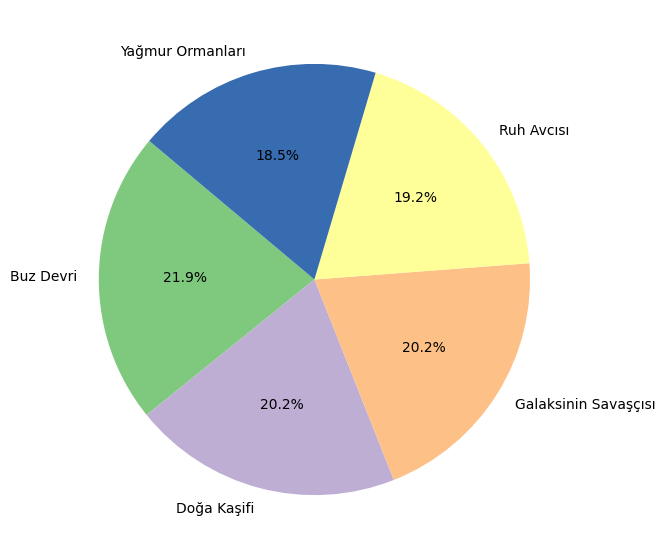

In [29]:
plt.figure(figsize=(7,7))
plt.pie(top5_shows["oynanma_oran"],labels=top5_shows["oyunad"],autopct="%1.1f%%",startangle=140,colors=plt.cm.Accent.colors, )
plt.show()